In [71]:
#Graduate_Admission_Prediction 

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

In [73]:
df=pd.read_csv('Admission_Predict.csv')
df

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,1,337,118,4,4.5,4.5,9.65,1,0.92
1,2,324,107,4,4.0,4.5,8.87,1,0.76
2,3,316,104,3,3.0,3.5,8.00,1,0.72
3,4,322,110,3,3.5,2.5,8.67,1,0.80
4,5,314,103,2,2.0,3.0,8.21,0,0.65
...,...,...,...,...,...,...,...,...,...
395,396,324,110,3,3.5,3.5,9.04,1,0.82
396,397,325,107,3,3.0,3.5,9.11,1,0.84
397,398,330,116,4,5.0,4.5,9.45,1,0.91
398,399,312,103,3,3.5,4.0,8.78,0,0.67


In [74]:
#Explore Dataset
df.info()
df.columns
df.columns.isnull()
df.describe()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Serial No.         400 non-null    int64  
 1   GRE Score          400 non-null    int64  
 2   TOEFL Score        400 non-null    int64  
 3   University Rating  400 non-null    int64  
 4   SOP                400 non-null    float64
 5   LOR                400 non-null    float64
 6   CGPA               400 non-null    float64
 7   Research           400 non-null    int64  
 8   Chance of Admit    400 non-null    float64
dtypes: float64(4), int64(5)
memory usage: 28.3 KB


Serial No.           0
GRE Score            0
TOEFL Score          0
University Rating    0
SOP                  0
LOR                  0
CGPA                 0
Research             0
Chance of Admit      0
dtype: int64

In [75]:
df['Chance of Admit '].describe()
df['Chance of Admit '].value_counts()


Chance of Admit 
0.64    17
0.71    16
0.72    15
0.73    13
0.76    12
0.78    12
0.70    12
0.94    12
0.79    12
0.80    11
0.74    11
0.68    10
0.65     9
0.84     9
0.62     9
0.89     9
0.93     9
0.90     8
0.75     8
0.86     8
0.82     8
0.57     8
0.77     8
0.81     8
0.61     7
0.66     7
0.91     7
0.96     7
0.69     7
0.67     7
0.92     6
0.63     6
0.56     6
0.85     6
0.52     5
0.54     5
0.46     5
0.58     5
0.87     5
0.47     5
0.95     4
0.97     4
0.88     4
0.49     4
0.59     4
0.44     3
0.48     3
0.53     3
0.42     3
0.83     3
0.50     2
0.45     2
0.36     2
0.38     2
0.34     2
0.55     1
0.60     1
0.43     1
0.51     1
0.39     1
Name: count, dtype: int64

<Axes: >

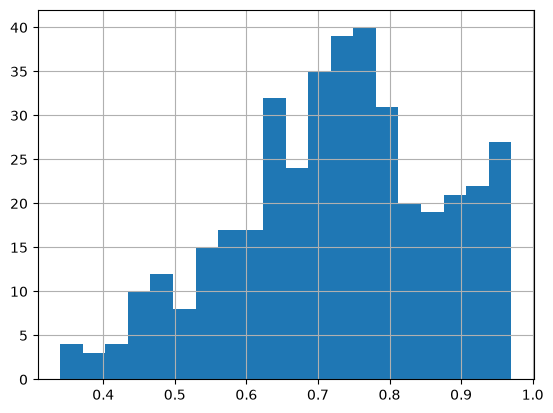

In [76]:
df["Chance of Admit "].hist(bins=20)

In [210]:
df["Chance of Admit "].value_counts().sort_index()



Chance of Admit 
0.34     2
0.36     2
0.38     2
0.39     1
0.42     3
0.43     1
0.44     3
0.45     2
0.46     5
0.47     5
0.48     3
0.49     4
0.50     2
0.51     1
0.52     5
0.53     3
0.54     5
0.55     1
0.56     6
0.57     8
0.58     5
0.59     4
0.60     1
0.61     7
0.62     9
0.63     6
0.64    17
0.65     9
0.66     7
0.67     7
0.68    10
0.69     7
0.70    12
0.71    16
0.72    15
0.73    13
0.74    11
0.75     8
0.76    12
0.77     8
0.78    12
0.79    12
0.80    11
0.81     8
0.82     8
0.83     3
0.84     9
0.85     6
0.86     8
0.87     5
0.88     4
0.89     9
0.90     8
0.91     7
0.92     6
0.93     9
0.94    12
0.95     4
0.96     7
0.97     4
Name: count, dtype: int64

In [231]:
#convert regression y column in catagorical form for classification
#make func before ->apply and then call func 

def admission(x):
    if x>=0.70: 
     return "Admitted"
    else: 
     return "Not Admitted" 
df["Admission"]=df["Chance of Admit "].apply(admission)
df[["Chance of Admit ","Admission"]]



,Chance of Admit,Admission
0,0.92,Admitted
1,0.76,Admitted
2,0.72,Admitted
3,0.80,Admitted
4,0.65,Not Admitted
...,...,...
395,0.82,Admitted
396,0.84,Admitted
397,0.91,Admitted
398,0.67,Not Admitted


In [214]:
df["Admission"].value_counts()
df["Admission"].value_counts(normalize=True)#for getting percentage
df


,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit,Admission
0,1,337,118,4,4.5,4.5,9.65,1,0.92,Admitted
1,2,324,107,4,4.0,4.5,8.87,1,0.76,Admitted
2,3,316,104,3,3.0,3.5,8.00,1,0.72,Admitted
3,4,322,110,3,3.5,2.5,8.67,1,0.80,Admitted
4,5,314,103,2,2.0,3.0,8.21,0,0.65,Not Admitted
...,...,...,...,...,...,...,...,...,...,...
395,396,324,110,3,3.5,3.5,9.04,1,0.82,Admitted
396,397,325,107,3,3.0,3.5,9.11,1,0.84,Admitted
397,398,330,116,4,5.0,4.5,9.45,1,0.91,Admitted
398,399,312,103,3,3.5,4.0,8.78,0,0.67,Not Admitted


In [232]:

mapping={'Not Admitted':0,"Admitted":1}
df["Admission"]=df["Admission"].map(mapping)
X=df.iloc[:,1:7]
X
Y=df.iloc[:,9]





In [233]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42)
Y_test

209    0
280    0
33     1
210    1
93     0
      ..
246    1
227    0
369    0
176    1
289    1
Name: Admission, Length: 80, dtype: int64

In [239]:
from sklearn.preprocessing import StandardScaler
scalar=StandardScaler()
X_train=scalar.fit_transform(X_train)
X_test=scalar.fit_transform(X_test)



In [240]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression()
model.fit(X_train,Y_train)
y_pred=model.predict(X_test)

In [242]:
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score,recall_score,f1_score,classification_report
print("Accuracy",accuracy_score(Y_test,y_pred))
print("confusion_matrix",confusion_matrix(Y_test,y_pred))
print("precision_score",precision_score(Y_test,y_pred))
print("recall_score",recall_score(Y_test,y_pred))
print("f1_score",f1_score(Y_test,y_pred))
# print(classification_report(Y_test,y_pred))

Accuracy 0.9125
confusion_matrix [[30  2]
 [ 5 43]]
precision_score 0.9555555555555556
recall_score 0.8958333333333334
f1_score 0.9247311827956989


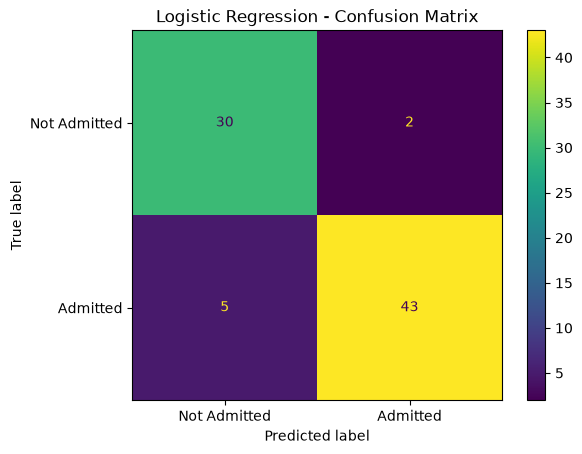

In [243]:
from sklearn.metrics import  ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(Y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not Admitted", "Admitted"]
)

disp.plot()
plt.title("Logistic Regression - Confusion Matrix")
plt.savefig("Images/confusion_matrix.png")
plt.show()


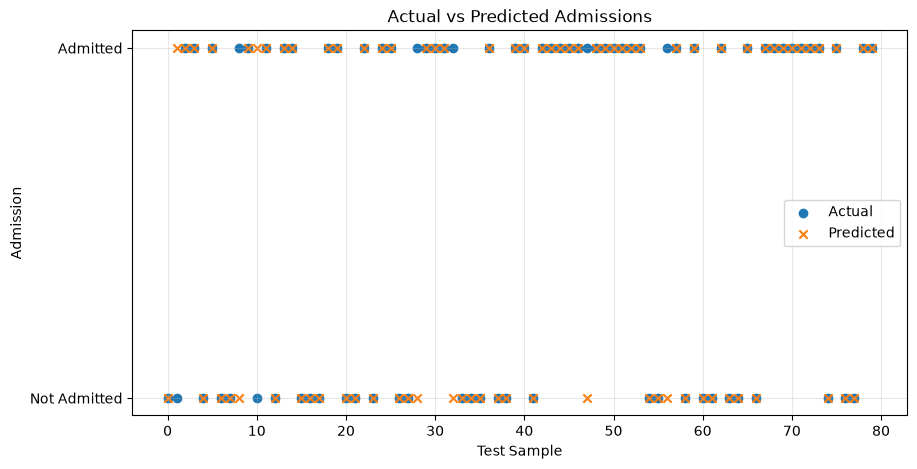

In [244]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.scatter(range(len(Y_test)), Y_test, label="Actual")
plt.scatter(range(len(y_pred)), y_pred, marker="x", label="Predicted")

plt.yticks([0, 1], ["Not Admitted", "Admitted"])
plt.xlabel("Test Sample")
plt.ylabel("Admission")
plt.title("Actual vs Predicted Admissions")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("Images/Actual vs Predicted Admissions.png")

plt.show()